## Block 1: Graph Representations

### 1. Micro-Revise: The Core Ideas
   To analyse graphs algorithmically, we must translate visual nodes and arcs 
   into data structures. The two standard methods are matrices and lists.

   - ADJACENCY MATRIX: A 2D grid where the cell at row i and column j contains
     the number of arcs connecting node i to node j.
     - For an undirected graph, the matrix is symmetric across the main
       diagonal.
     - THE LOOP RULE: A loop (an arc connecting a node to itslef) contributes
       TWICE to the diagonal entry $(i, i)$. This specific convention ensures
       that if you sum all the numbers in a single row, you get the exact degree
       of that node.

   - ADJACENCY LIST: An array of linked lists where the i-th list contains all
     the nodes adjacent to node i.
      - If there are parallel arcs between i and j, j appears multiple times in
        i's list.
      - THE LOOP RULE: A loop on node i is only recorded ONCE in i's adjacency
        list.

   - DEGREE: The degree of a node is the total number of incident arcs. You can
     find a node's degree instantly by summing its row in the adjacency matrix.
     
                      

---

## Block 2: Isomorphism and Automorphisms
   Let's break down... Both concepts deal with the fundamental "shape" of a 
   graph, ignoring how it's drawn on a page or what the nodes happen to be named


### 1. Isomorphism: "Same Structure, relabelled"#
   Imagine you build a graph out of nodes and arcs. If you throw it on the floor
   , the strings might cross in a messy tangle. If you stretch it out nicely
   on a table, it might look like a perfect hexagon. Even though the drawings
   look completely different, it's the exact same set of beads and strings.

   Two graphs are ISOMORPHIC if you can find a perfect 1-to-1 matching (a 
   bijection) between their nodes s.t. the connections are perfectly preserved.

   THE GOLDEN RULE FOR ISOMORPHISM: To quickly prove two graphs are not
   isomorphic, look at their DEGREE PATTERN. If Graph A has a node with 5 
   connections, Graph B must have a node with 5 connections. If their degree
   don't match exactly, they are fundamentally different shapes.


### 2. Automorphism: "Symmetry of one graph"
   An automorphism is an isomorphism from a graph to itself. Intuitively, it 
   asks: "HOW MANY WAYS CAN YOU PICK UP THIS GRAPH, SHUFFLE THE NODES AROUND,
   AND PLACE IT PERFECTLY BACK INTO ITS OWN FOOTPRINT?"   


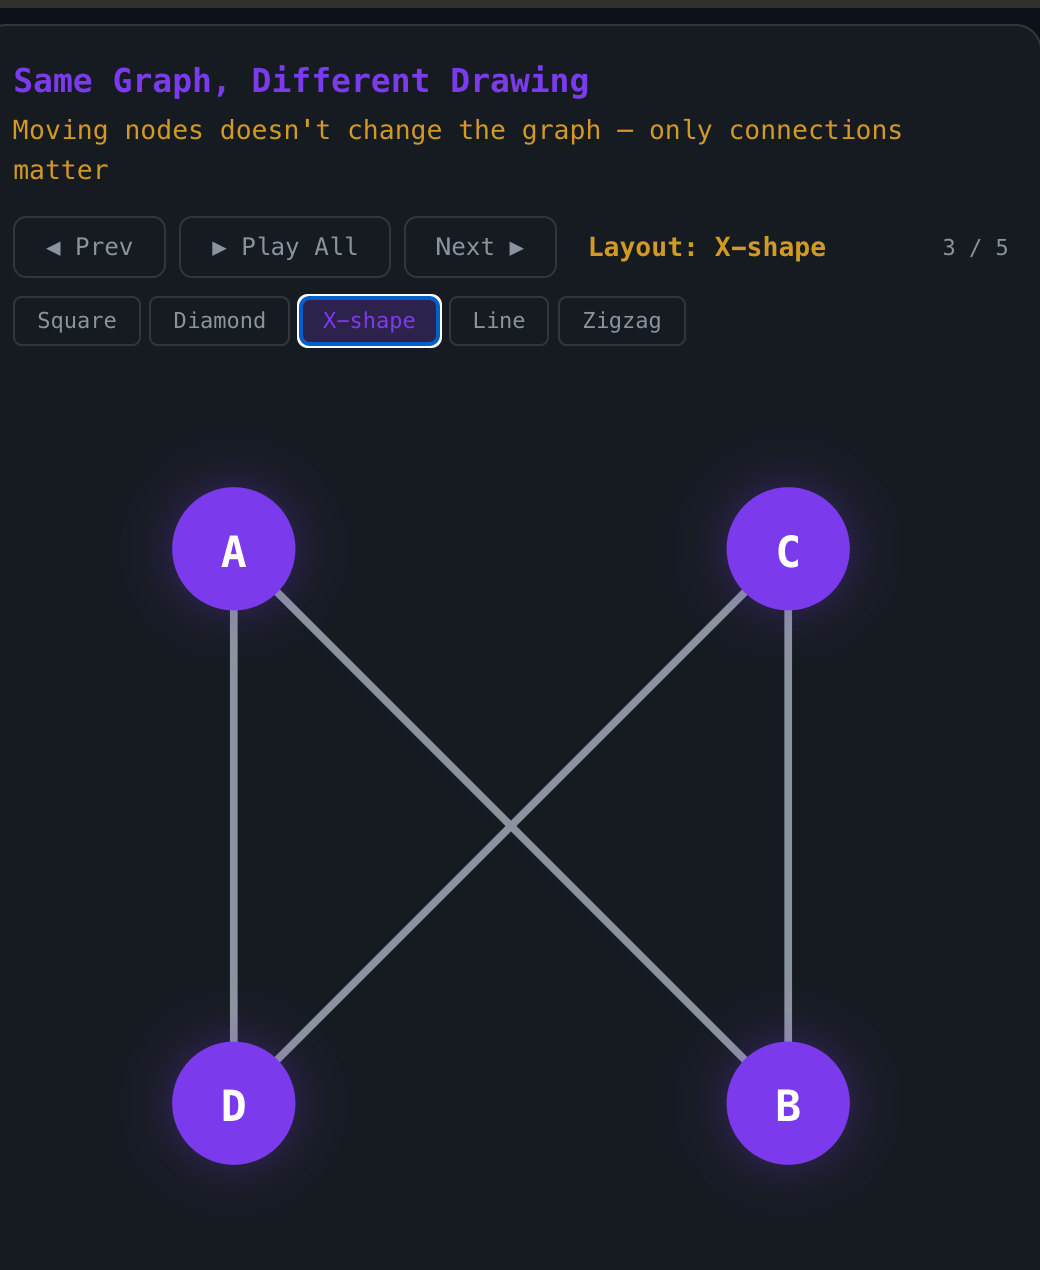

### 2. Automorphism: "Symmetry of one graph"
   An automorphism is an isomorphism from a graph to itself. Intuitively, it
   asks: "HOW MANY WAY CAN YOU PICK UP THIS GRAPH, SHUFFLE THE NODES AROUND, 
   AND PLACE IT PERFECTLY BACK INTO ITS OWN FOOTPRINT?"

   Every graph has at least 1 automorphism: the "identity" mapping, which just 
   leaves every node exactly where it is. If a graph has structural symmetry, it
   will have more.


3. THE STRATEGY: "Forced Nodes" and "Degrees"
   When calculating how many automorphisms a graph has, ever try to guess the
   total randomly. Build it up step-by-step using "forced nodes":

   - STEP 1: Find the anchors (Forced Nodes). Look for nodes with unique 
     degrees. If a node is the only degree-4 node in the entire graph, it is
     locked in place. It can only ever map to itself.
   - STEP 2: LOOK AT THEIR NEIGHBORS. If Node A is locked in place, any node 
     connected to it must map to another node connected to it.
   - STEP 3: COUNT THE INDEPENDENT CHOICES. Multiply the number if valid
     choices for each symmetric part. 


   ...          

## Block 3: Planarity, Colouring, and Bipartite Graphs
   ... we are looking at how graphs can be drawn, how their nodes can be grouped
   , and what structural "traps" prevent certain groupings.


### 1. Planar Intuition   
   A graph is PLANAR if you can draw it on a flat piece of paper without any of
   its edges crossing over each other. Think of it like designing a printed
   circuit board--wires cannot cross unless there is a physical junction (a
   node) there.

   When you draw a connected planar graph, it naturally divides the paper into
   enclosed regions called FACES (the "outside" of the graph also counts as one
   massive face).

   There is a beautiful, rigid mathematical law that binds the graph together,
   known as EULER'S FORMULA: $F = A - N + 2$ (Faces = Arcs - Nodes + 2)


### 2. Graph Colouring
   Graph colouring is exactly what it sounds like: assingining a colour to every
   node. The only absolute rule is: NO TWO ADJACENT NODES (nodes connected by an
   arc) CAN HAVE THE SAME COLOUR. It's like colouring a political map where
   neighbouring countries must look distinct. If a graph can be coloured using a
   maximum of $k$ colours, we call it k-colourable.


### 3. Bipartite Graphs = 2-Colourable
   A graph is BIPARTITE if you can split all its node into two distinct, 
   isolated camps (let's call them Left and Right). All arcs must go across the
   divide, from a Left node to a Right node. There can be absolutely zero 
   internal connections within the Left camp, or within the Right camp.

   - THE GOLDEN RULE: A graph is bipartite IF AND ONLY IF it is exactly 
     2-colourable. Why? Because you can jsut paint the entire Left camp "Red"
     and the entire Right camp "Blue". Since there are no internal arcs within
     the camps, no two Red nodes will ever touch, and no two Blue nodes will
     ever touch. 


### 4. The Odd Cycle Obstruction
   So, what stops a graph from being bipartite (2-colourable)? Odd-length cycles

   Think of a simple triangle (a cycle of 3 nodes). Let's try to 2-colour it:

      ... forced to introduce a 3rd colour. FAILED!

   This logic applies to any cycle of odd length (3, 5, 7, etc.). By the time
   you alternate colours around the loop and get back to the start, you will
   clash with the first colour. Therefore, IF A GRAPH HAS AN ODD CYCLE, IT IS
   NOT 2-COLOURABLE, AND THEREFORE NOT BIPARTITE.    


### Block 4: Euler Circuits and Almost-Eulerian Graphs
   ... theory for traversing edges. While Hamiltonian problems care about
   visiting every node, Eulerian problems care about traversing every arc. Think
   of it as the "Railway Inspector's Problem": you need to inspect every single
   stretch of track exactly once. 


1. Euler Path vs. Euler Circuit
   - EULER PATH: A route through a graph that traverses EVERY ARC EXACTLY ONCE.
     You are allowed to pass through the same node multiple tiems.
   - EULER CIRCUIT: An Euler path that STARTS AND FINISHES AT THE EXACT SAME
     NODE. 


2. The Degree Condition (The "In-and-Out" Rule)
   To figure out if an Euler circuit or path exists, you never need to blindly
   trace paths with your finger; you only need to look at the DEGREE OF THE 
   NODES.

   Imagine you are walking through a node. Every time you enter a node, you must
   also leave it. That means every "visit" to a node "uses up" exactly two of 
   its incident arcs.

   - FOR AN EULER CIRCUIT: Because you eventually leave every node you enter
     (until you return to the start at the very end), EVERY SINGLE NODE IN THE
     GRAPH MUST HAVE AN EVEN DEGREE (The graph must also be connected).
   - FOR AN EULER PATH (non-circuit): You start at one specific node (using 1
     arc to leave) and end at another specific node (using 1 arc to enter and 
     leave) and end at another specific node (using 1 arc to enter and stop).
     Therefore, EXACTLY TWO NODES must have an odd degree (these are your start
     and end points), and all other nodes must be EVEN.     

---

## Block 1: DFS and BFS
   ... Both DFS and BFS are ways to systematically visit every node in a 
   connected graph, but they have completely different "personalities."


1. DFS: The Maze Runner (Stack-like)
   Imagine you are exploring a deep maze. Your strategy is to keep walking 
   forward taking the first available turn, going as deep as possible until you
   hitb a dead end. When you can't go any further, you BACKTRACK to the last 
   junction and try the next available path.

   - MECHANISM: DFS operates like a Stack (LIFO). You plunge deep into the 
     graph, and the most recently discovered node is the one you explore next.
     It is naturally implemented using recursion.
   - THE RULE: When faced with multiple adjacent nodes, you always pick one
     (in exams, usually the NUMERICALLY LOWEST), immediately move to it, and
     suspend your current position until you hit a dead end. 
   - THE SPANNING TREE: Because it dives deep before spreading out, a DFS 
     spanning tree tends to look long, linear, and spindly.


2. BFS: The Ripple in a Pond (Queue-like)
   Imagine dropping a pebble into a pond. The ripple spread outward in 
   concentric circles. BFS visits everything at distance 1 first, then 
   everything at distance 2, and so on.

   - MECHANISM: BFS operates like a QUEUE (First-in, First-Out). You standa at a
     node, look at all its immediate neighbors, and add them to the back of a
     waiting line (the queue). Then you process the queue in the exact order
     people joined it. 
   - THE RULE: You completely exhaust a node's immediate neighbors before you
     take a single step deeper into the graph.
   - THE SPANNING TREE: Because it explores in layers, a BFS spanning tree is
     short and bushy. Crucially, the depth of a node in a BFS tree tells you its
     SHORTEST PATH DISTANCE from the start node. 



            


---

## Block 2: Topological Sort and DAG Logic
   ... theory for directed graphs without cycles. This is all about DEPENDENCY
   and ORDER.


### 1. The DAG (Directed Acylic Graph)   
   A DAG is a graph where the arcs have arrows (direction), and there is 
   absolutely no way to follow the arrows and end up back where you started (no
   cycles).

   Imagine assembling a custom FPV drone... A DAG perfectly models these valid,
   loop-free pre-requisites.


### 2. TOPOLOGICAL SORT: The "Valid Build Order"   
   A TOPOLOGICAL SORT takes the messy web of a DAG and flattens it into a single
   , straight line of nodes (a list).

   The one strict rule: FOR EVERY ARC $A \to B$, node $A$ MUST appear before $B$
   in the flattened list. 

   If the graph has a cycle, a topological sort is mathematically impossible. 


### 3. The Magic of DFS "Exit Order"
   ... can find a topological sort effortlessly using DFS. Here is the trick:
   you don't care about the order nodes are entered (visited). You only care
   about the order they are EXITED (when the recursive call finishes because
   there's nowhere left to go).

   * THE INTUITION: When DFS hits a dead end, it means that node has no further
     dependencies to trigger. In our drone analogy it's a foundational step 
     that relies on nothing else (or its dependencies are already processed).
   * DFS "exits" the deepest, most foundational nodes first. It exits the 
     "final" steps of a process before the "initial" steps.
   * Therefore, the EXIT ORDER gives you the sequence of tasks in reverse.


THE GOLDEN ALGORITHM FOR TOPOLOGICAL SORT:
   1. Run standard DFS
   2. Every time a node has no unvisited neighbors and you are about to 
      backtrack, write that node down. (This is the Exit Order).
   3. When the entire DFS is done, REVERSE the list you wrote down. That is 
      your Topological Sort.    

---

-- Prim: grows tree from start node, always picks cheapest crossing edge.

-- Kruskal: processes edges glbally in weight order, rejects if cycle (same
   component in union-find). Union-find parent tree shown for Kruskal - roots
   are marked amber with their component sign. 

## Block 3: Prim and Kruskal (Minimum Spanning Trees)
   ... finding the cheapest way to connect everything. A SPANNING TREE connects
   all nodes in a graph without any ccles. A MINIMUM SPANNING TREE (MST) does
   tghis using the smallest possible total edge weight.

   ... two famous algorithms... very different...


1. PRIM'S ALGORITHM: The "Growing Blob"
   Prim's builds the MST by starting at one specific node and continuously
   expanding a single, connected tree.

   - THE STRATEGY:
      1. Start at a chosen root node.
      2. Look at all the edges connecting your current tree to the "outside 
         world" (unvisited nodes).
      3. Pick the absolute cheapest edge. Add that edge and the new node to your
         tree.
      4. Repeat until all nodes are sucked into the blob.
   - VISUAL INTUITION: Imagine a puddle of water slowly expanding. It can only
     absorb new territory that is directly touching its current borders, always
     seeking the path of least resisance (lowest weight).


2. Kruskal's Algorithm: The "Greedy Sorter"        
   Kruskal doesn't care about staying connected during the process. It builds 
   the MST by grabbing the cheapest edge anywhere in the graph and slowly 
   stitching them together into a final tree.

   - THE STRATEGY:
      1. Throw all edges into a list and sort them from cheapest to most 
         expensive.
      2. Go down the list, picking up edges one by one.
      3. THE ONLY RULE: If an edge forms a cycle with the edges you've already
         picked, throw it away. Otherwise, keep it.
      4. Stop when you have $N - 1$ edges (where $N$ is the number of nodes).
   - VISUAL INTUITION: Imagine having a bucket of sticks of various length. You
     always reach for the shortest stick available. You lay them down on the
     table. Sometimes they form disconnected little groups (a "forest"), but 
     eventually, teh short sticks bridge the gaps, formming one massive tree.


3. MST UNIQUENESS: Do Ties Matter?
   - If every single edge in a graph has a completely UNIQUE, DISTINCT WEIGHT,
     the graph will have exactly ONE UNIQUE MST. 
   - If some edges share the same weight (e.g., you have three edges with a 
     weight of 5), you might have a choice to make. If picking one tied edge
     over other results in a different valid tree with the same minimum total
     weight, the MST is NOT UNIQUE. 


4. UNION-FIND in Kruskal's (The Cycle Checker) 
   How does a computer actually know if an edge creates a cycle in Kruskal's? It
   uses a "Union-Find" data structure with "Leaders".

   - Every connected group of nodes elects a "Leader."
   - When considering edge $A - B$, the computer checks: "Who is A's leader? Who
     is B's leader?"
   - If they have the same leader, they are already connected. Adding $A - B$ 
     would make a cycle! Reject it. 
   - ... unsure what's going on... will ask Claude to render an artifact instead
     which demonstrates how this work step by step via and artifact...   

